# 02 — Zone Detection Analysis

**Goal:** Test and visually validate the Swing High / Swing Low zone detection system.

Steps in this notebook:
1. Load real processed data (RELIANCE.NS or any dev symbol)
2. Run zone detection with different lookback values (N=3, 5, 10)
3. Plot detected zones as coloured bands on a candlestick chart
4. Understand the effect of the lookback parameter
5. Run merger and scorer — see how zones consolidate and get scored
6. Analyse zone statistics

**Pre-requisites:**
```bash
python run_data_pipeline.py --mode dev
```

In [19]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/sachinchoudhary/Desktop/RI/ZoneTrend


In [20]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import mplfinance as mpf
warnings.filterwarnings('ignore')

from src.zones import ZoneConfig, detect_swing_zones, merge_zones, score_zones, get_nearby_zones, zone_summary

cfg = ZoneConfig()
print(f'ZoneConfig loaded')
print(f'  swing.lookback            = {cfg.swing.lookback}')
print(f'  merger.merge_distance_atr = {cfg.merger.merge_distance_atr}')
print(f'  scorer weights            = touch={cfg.scorer.weights.touch}, move={cfg.scorer.weights.move}, freshness={cfg.scorer.weights.freshness}, width={cfg.scorer.weights.width}')

ZoneConfig loaded
  swing.lookback            = 5
  merger.merge_distance_atr = 0.3
  scorer weights            = touch=0.3, move=0.35, freshness=0.2, width=0.15


---
## 1. Load Data

Tries to load real processed data from `data/processed/`.
If not yet available, falls back to synthetic data so you can still run this notebook.

In [21]:
# ── Change this to any symbol from your dev_symbols list ──
SYMBOL = 'RELIANCE.NS'

# ── Try loading real processed data first ─────────────────
from src.data.data_loader import DataLoader

loader = DataLoader(source='processed')
df     = loader.load_symbol(SYMBOL)

if df is not None:
    print(f'Real data loaded: {SYMBOL}')
    print(f'  Rows      : {len(df)}')
    print(f'  Date range: {df.index.min().date()} to {df.index.max().date()}')
    print(f'  Columns   : {list(df.columns)}')
    DATA_SOURCE = 'real'

else:
    print(f'Processed data for {SYMBOL} not found in data/processed/')
    print('Run: python run_data_pipeline.py --mode dev')
    print()
    print('Falling back to SYNTHETIC data for demonstration...')

    # ── Synthetic fallback ─────────────────────────────────
    def _make_synthetic(n=500, seed=42):
        np.random.seed(seed)
        dates = pd.date_range('2020-01-01', periods=n, freq='B')
        regimes = [(100,+0.4),(80,-0.3),(120,+0.5),(80,+0.05),(120,-0.4)]
        closes = [2500.0]
        for length, drift in regimes:
            for _ in range(length):
                closes.append(closes[-1] * (1 + drift/252 + np.random.randn()*0.015))
        closes = np.array(closes[1:n+1])
        dv = closes * 0.012
        high  = closes + np.abs(np.random.randn(n))*dv*0.8
        low   = closes - np.abs(np.random.randn(n))*dv*0.8
        open_ = closes + np.random.randn(n)*dv*0.4
        high  = np.maximum(high, np.maximum(open_, closes))
        low   = np.minimum(low,  np.minimum(open_, closes))
        vol   = np.abs(np.random.randn(n)*1e6+5e6)
        df = pd.DataFrame({'Open':open_,'High':high,'Low':low,'Close':closes,'Volume':vol}, index=dates)
        df.index.name = 'Date'
        prev = df['Close'].shift(1)
        tr = pd.concat([df['High']-df['Low'],(df['High']-prev).abs(),(df['Low']-prev).abs()],axis=1).max(axis=1)
        df['ATR'] = tr.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
        return df

    df = _make_synthetic()
    DATA_SOURCE = 'synthetic'
    print(f'Synthetic data ready: {len(df)} candles | {df.index.min().date()} to {df.index.max().date()}')

print(f'\nData source: {DATA_SOURCE}')
df.tail(3)

Real data loaded: RELIANCE.NS
  Rows      : 5544
  Date range: 2004-01-01 to 2026-05-29
  Columns   : ['Open', 'High', 'Low', 'Close', 'Volume', 'TrueRange', 'ATR', 'IsOutlier', 'LogReturn', 'RollingVolatility', 'CandleBody', 'UpperWick', 'LowerWick', 'CandleRange', 'IsBullish', 'BodyRatio', 'UpperWickRatio', 'LowerWickRatio', 'BodyToATR', 'RangeToATR', 'SMA20', 'EMA20', 'SMA50', 'EMA50', 'SMA200', 'EMA200', 'VolumeMA20', 'VolumeRatio']

Data source: real


,Open,High,Low,Close,Volume,TrueRange,ATR,IsOutlier,LogReturn,RollingVolatility,...,BodyToATR,RangeToATR,SMA20,EMA20,SMA50,EMA50,SMA200,EMA200,VolumeMA20,VolumeRatio
Date,,,,,,,,,,,,,,,,,,,,,
2026-05-27,1353.0,1361.0,1348.599976,1350.500000,13215138,12.400024,27.178428,0,-0.004286,0.013703,...,0.091985,0.456245,1385.150000,1367.069611,1373.258003,1380.144986,1429.282752,1409.845702,15893156.55,0.831499
2026-05-28,1350.5,1350.5,1350.500000,1350.500000,0,0.000000,25.237111,0,0.000000,0.013635,...,0.000000,0.000000,1381.134998,1365.491553,1372.654004,1378.982438,1429.104434,1409.255198,14345262.50,0.000000
2026-05-29,1364.0,1369.0,1317.000000,1321.199951,42634247,52.000000,27.148746,0,-0.021935,0.014258,...,1.576502,1.915374,1375.654993,1361.273305,1371.176003,1376.716458,1428.774136,1408.379026,16476974.85,2.587505


---
## 2. Detect Zones with Different Lookback Values

The default lookback comes from `zone_config.yaml → swing.lookback`.
Here we compare N=3, 5, 10 to understand the effect.

In [22]:
results = {}
for N in [3, 5, 10]:
    zones = detect_swing_zones(df, symbol=SYMBOL, lookback=N, cfg=cfg)
    results[N] = zones
    n_sup = (zones['zone_type']=='support').sum()
    n_res = (zones['zone_type']=='resistance').sum()
    print(f'Lookback N={N:2d} | Total: {len(zones):3d} zones | Support: {n_sup:3d} | Resistance: {n_res:3d}')

Lookback N= 3 | Total: 987 zones | Support: 504 | Resistance: 483
Lookback N= 5 | Total: 633 zones | Support: 322 | Resistance: 311
Lookback N=10 | Total: 321 zones | Support: 162 | Resistance: 159


---
## 3. Visual Validation — Zones on Candlestick Chart

**This is the most important step.**
Green bands = support zones. Red bands = resistance zones.
Ask yourself: do the zones match where the chart naturally shows support/resistance?

In [23]:
def plot_zones_on_chart(df, zones, title, n_candles=200, save_path=None):
    plot_df   = df[['Open','High','Low','Close','Volume']].tail(n_candles)
    price_min = plot_df['Low'].min()
    price_max = plot_df['High'].max()

    fig, axes = mpf.plot(
        plot_df, type='candle', style='charles',
        title=title, ylabel='Price (INR)',
        volume=True, figsize=(18, 10), returnfig=True
    )
    ax = axes[0]

    sup_count = res_count = 0
    for _, zone in zones.iterrows():
        if zone['upper_boundary'] < price_min*0.95 or zone['lower_boundary'] > price_max*1.05:
            continue
        color = '#2ecc71' if zone['zone_type'] == 'support' else '#e74c3c'
        ax.axhspan(zone['lower_boundary'], zone['upper_boundary'], color=color, alpha=0.15, linewidth=0)
        ax.axhline(zone['upper_boundary'], color=color, alpha=0.5, linewidth=0.6, linestyle='--')
        ax.axhline(zone['lower_boundary'], color=color, alpha=0.5, linewidth=0.6, linestyle='--')
        if zone['zone_type'] == 'support': sup_count += 1
        else: res_count += 1

    sup_patch = mpatches.Patch(color='#2ecc71', alpha=0.5, label=f'Support ({sup_count})')
    res_patch = mpatches.Patch(color='#e74c3c', alpha=0.5, label=f'Resistance ({res_count})')
    ax.legend(handles=[sup_patch, res_patch], loc='upper left', fontsize=10)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Visible zones: {sup_count} support | {res_count} resistance')

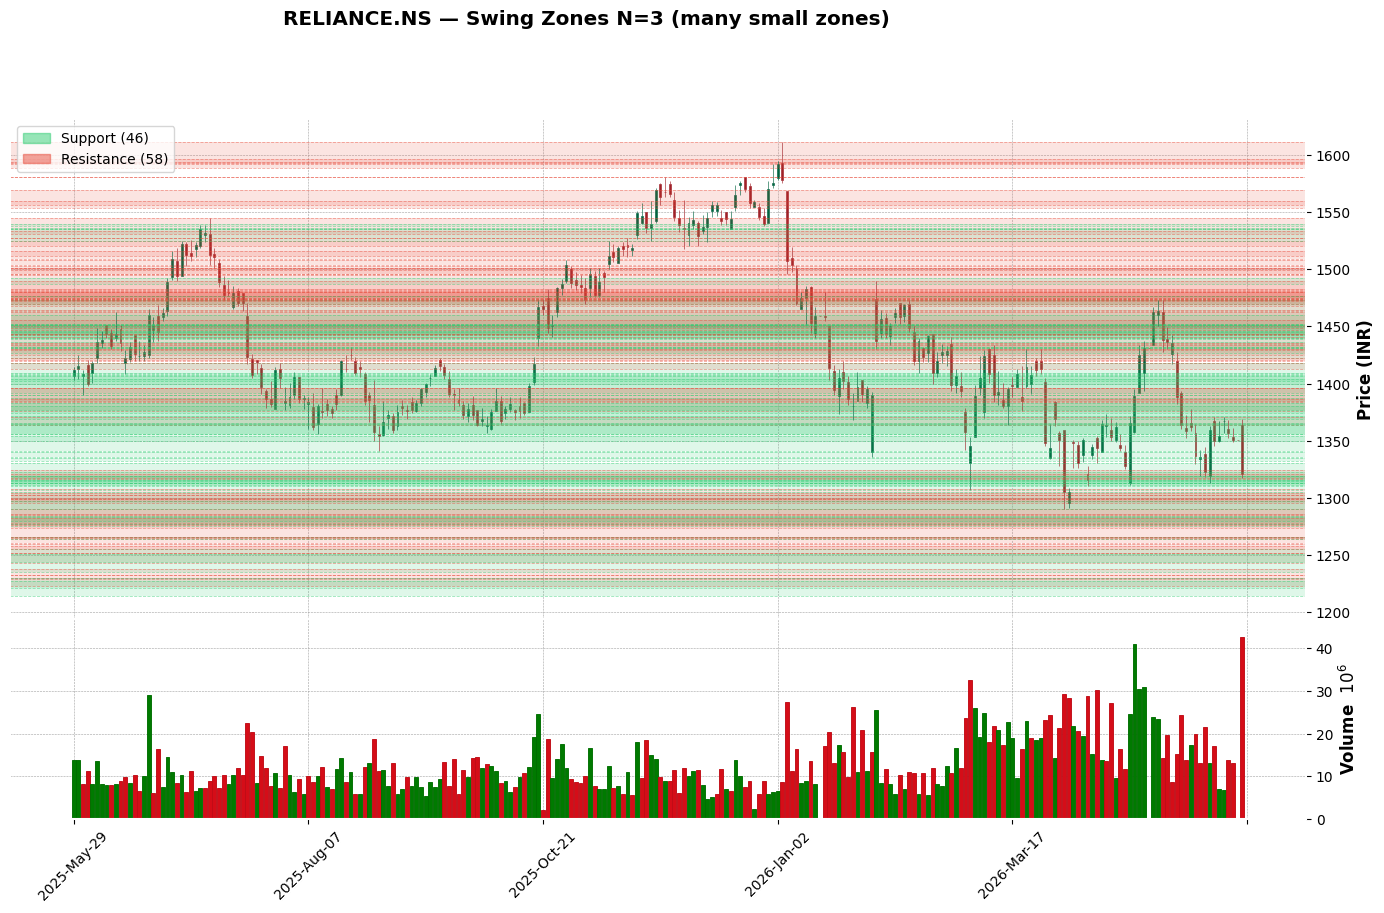

Visible zones: 46 support | 58 resistance


In [24]:
plot_zones_on_chart(df, results[3],
    title=f'{SYMBOL} — Swing Zones N=3 (many small zones)',
    n_candles=250,
    save_path=PROJECT_ROOT / 'data' / 'processed' / f'zones_N3_{SYMBOL.replace(".","_")}.png')

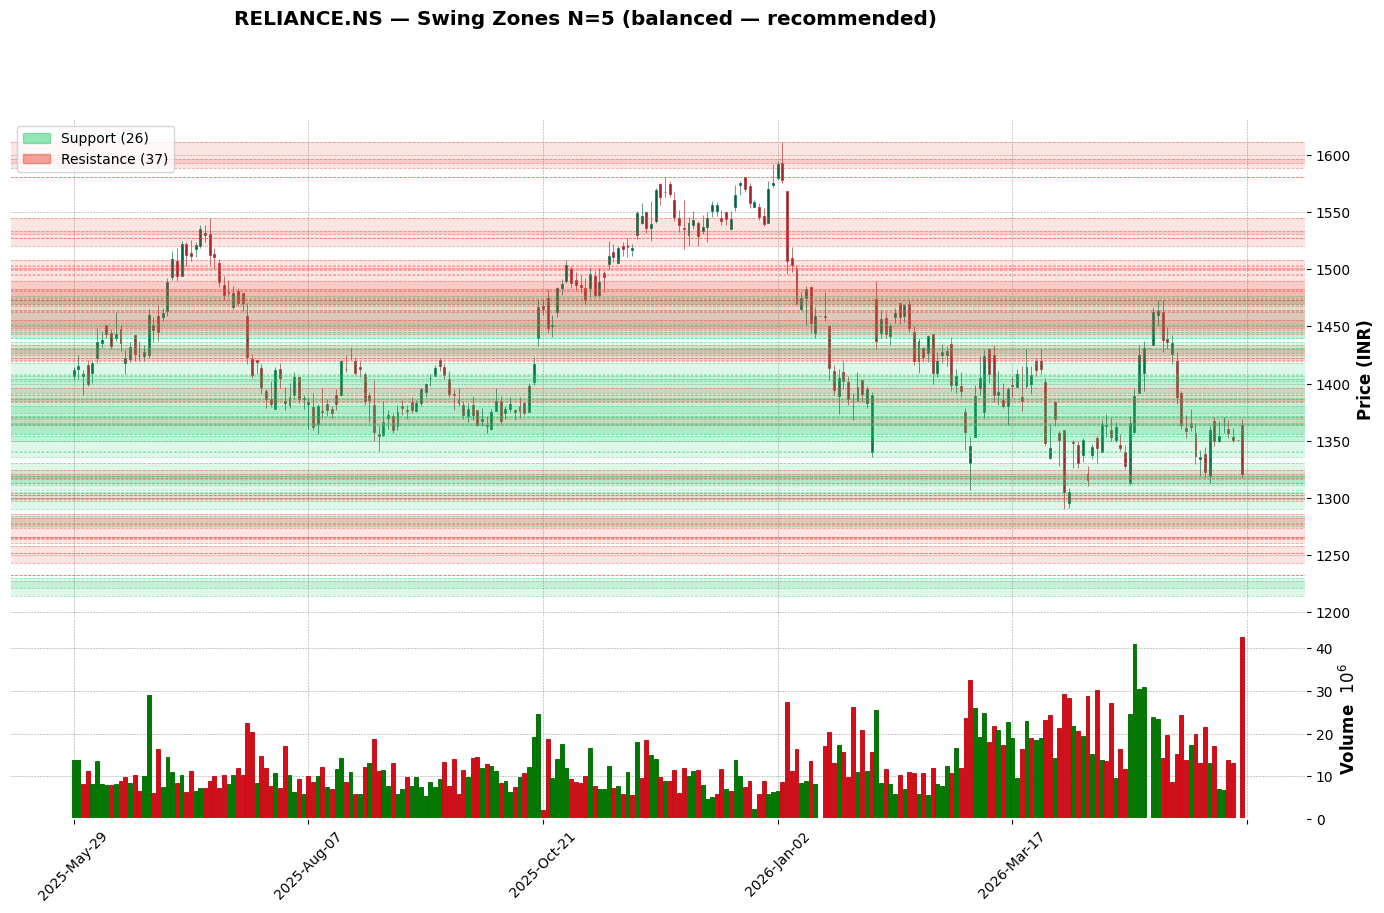

Visible zones: 26 support | 37 resistance


In [25]:
plot_zones_on_chart(df, results[5],
    title=f'{SYMBOL} — Swing Zones N=5 (balanced — recommended)',
    n_candles=250,
    save_path=PROJECT_ROOT / 'data' / 'processed' / f'zones_N5_{SYMBOL.replace(".","_")}.png')

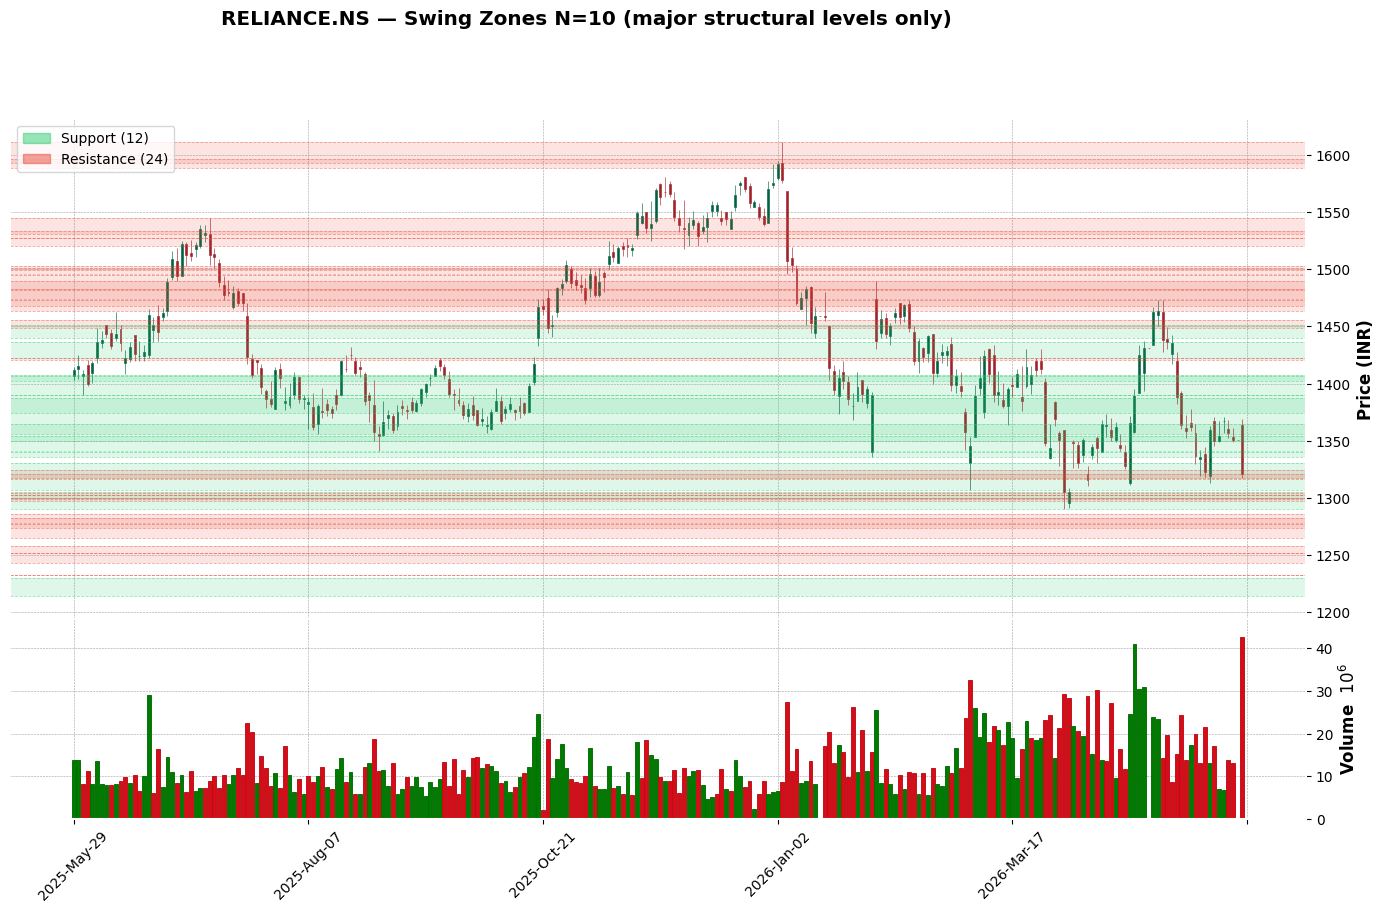

Visible zones: 12 support | 24 resistance


In [26]:
plot_zones_on_chart(df, results[10],
    title=f'{SYMBOL} — Swing Zones N=10 (major structural levels only)',
    n_candles=250,
    save_path=PROJECT_ROOT / 'data' / 'processed' / f'zones_N10_{SYMBOL.replace(".","_")}.png')

---
## 4. Effect of Merging

In [27]:
zones_raw    = results[5]
zones_merged = merge_zones(zones_raw, cfg=cfg)

print(f'Before merging : {len(zones_raw):3d} zones')
print(f'After merging  : {len(zones_merged):3d} zones')
print(f'Zones merged   : {len(zones_raw) - len(zones_merged)}')
print(f'\nSupport  — before: {(zones_raw["zone_type"]=="support").sum()} | after: {(zones_merged["zone_type"]=="support").sum()}')
print(f'Resistance — before: {(zones_raw["zone_type"]=="resistance").sum()} | after: {(zones_merged["zone_type"]=="resistance").sum()}')

Before merging : 633 zones
After merging  :  99 zones
Zones merged   : 534

Support  — before: 322 | after: 45
Resistance — before: 311 | after: 54


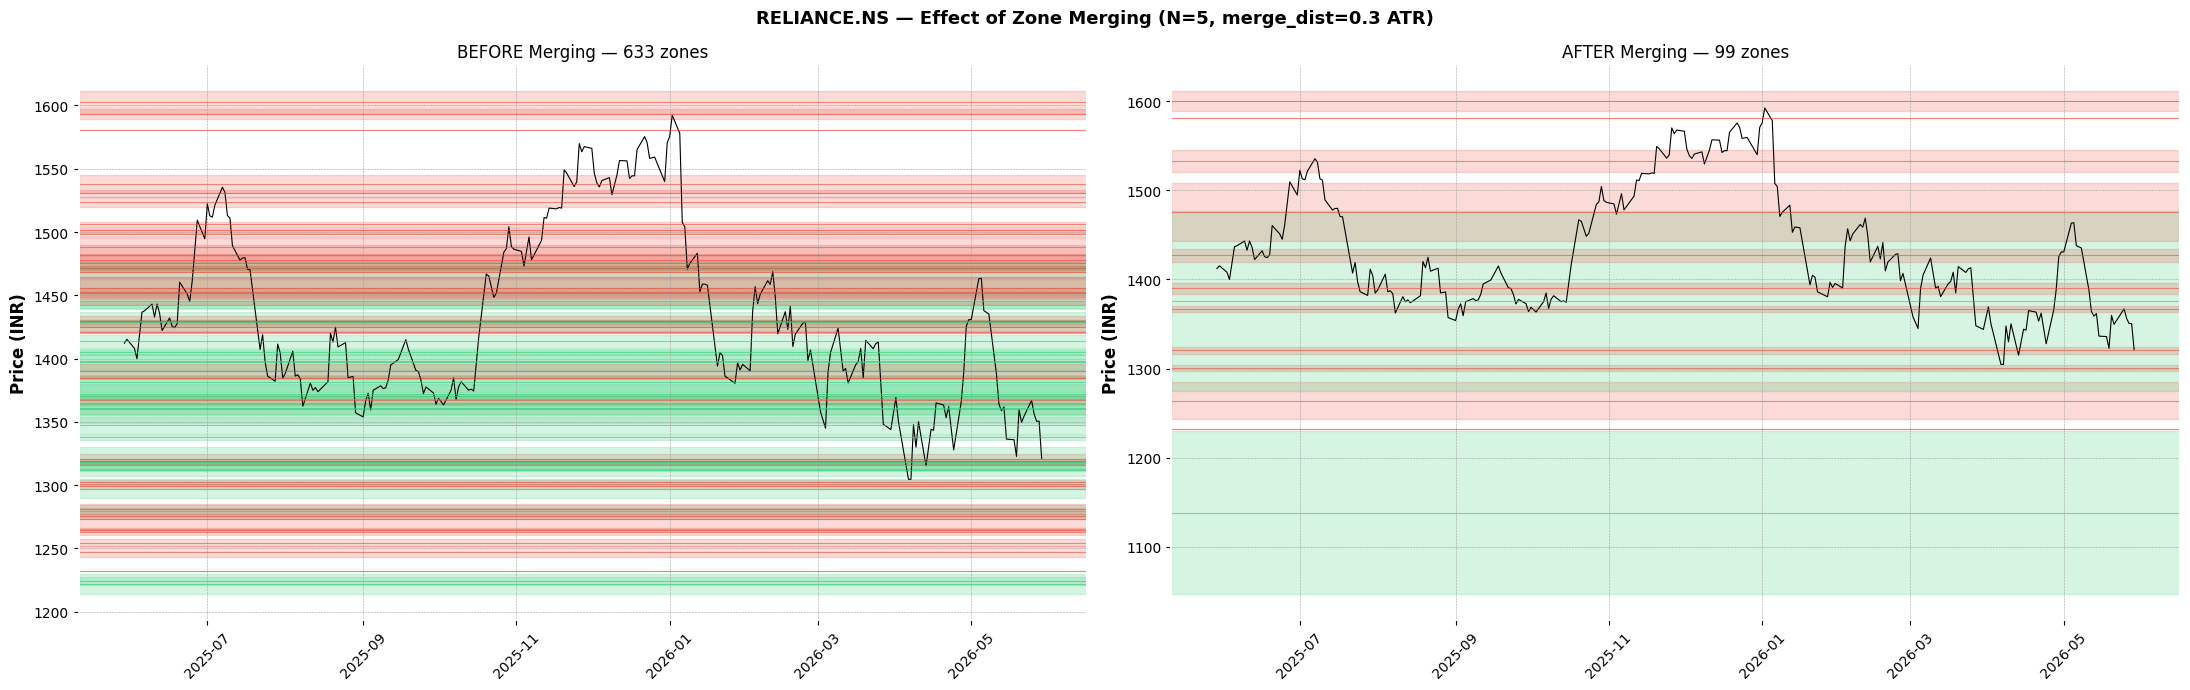

In [28]:
fig, axes_list = plt.subplots(1, 2, figsize=(22, 7))

def _draw(ax, df, zones, n_candles=200):
    plot_df = df[['Close']].tail(n_candles)
    ax.plot(plot_df.index, plot_df['Close'].values, color='black', linewidth=0.8)
    pmin = df['Low'].tail(n_candles).min(); pmax = df['High'].tail(n_candles).max()
    for _, z in zones.iterrows():
        if z['upper_boundary'] < pmin*0.95 or z['lower_boundary'] > pmax*1.05: continue
        c = '#2ecc71' if z['zone_type']=='support' else '#e74c3c'
        ax.axhspan(z['lower_boundary'], z['upper_boundary'], color=c, alpha=0.2)
        ax.axhline(z['midpoint'], color=c, alpha=0.6, linewidth=0.8)
    ax.set_ylabel('Price (INR)'); ax.tick_params(axis='x', rotation=45)

_draw(axes_list[0], df, zones_raw,    n_candles=250)
axes_list[0].set_title(f'BEFORE Merging — {len(zones_raw)} zones', fontsize=12)
_draw(axes_list[1], df, zones_merged, n_candles=250)
axes_list[1].set_title(f'AFTER Merging — {len(zones_merged)} zones', fontsize=12)
plt.suptitle(f'{SYMBOL} — Effect of Zone Merging (N=5, merge_dist={cfg.merger.merge_distance_atr} ATR)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT/'data'/'processed'/f'zones_merge_{SYMBOL.replace(".","_")}.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 5. Zone Scoring

In [29]:
zones_scored = score_zones(zones_merged, df, cfg=cfg)
print('Top 10 zones by strength:')
cols = ['zone_type','lower_boundary','upper_boundary','width_atr','touch_count','move_magnitude_atr','zone_strength']
zones_scored[cols].sort_values('zone_strength', ascending=False).head(10).round(3)

Top 10 zones by strength:


,zone_type,lower_boundary,upper_boundary,width_atr,touch_count,move_magnitude_atr,zone_strength
16,support,50.842,51.642,0.683,7,5.384,0.820
93,resistance,1589.138,1611.800,0.864,11,6.780,0.814
50,resistance,378.166,385.410,0.968,8,5.030,0.805
96,resistance,1316.791,1324.659,0.302,18,4.754,0.803
85,support,1022.457,1036.222,0.464,21,4.675,0.797
87,resistance,1297.295,1303.755,0.266,44,9.136,0.797
95,resistance,1363.753,1370.526,0.264,73,6.038,0.796
63,support,524.589,531.708,0.550,21,4.585,0.791
62,resistance,521.303,527.395,0.381,25,4.521,0.786
22,resistance,115.621,116.546,0.232,43,8.981,0.774


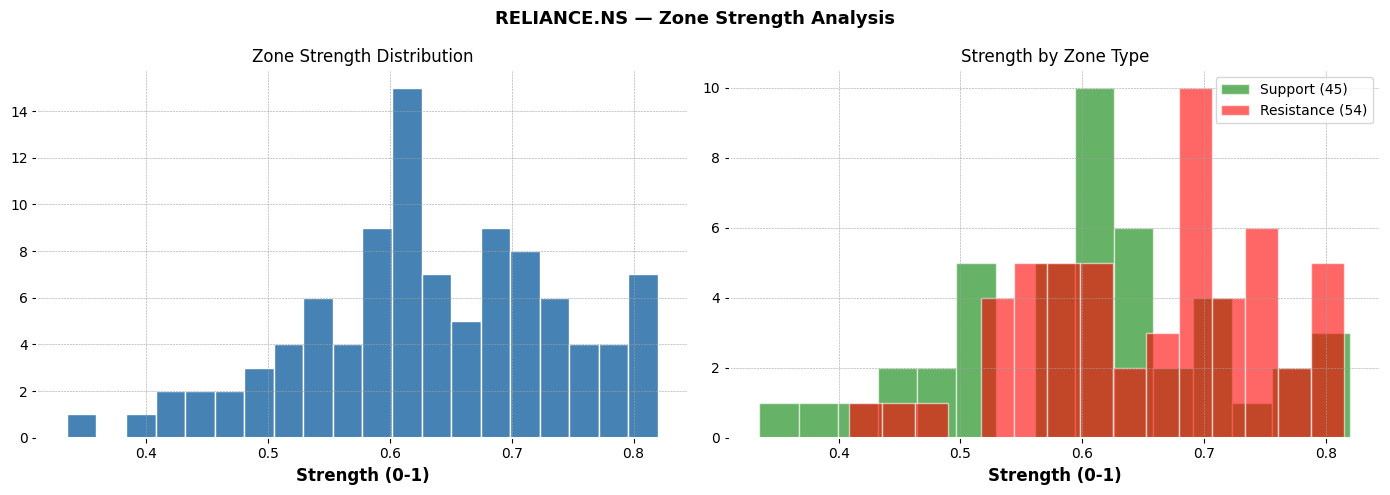

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
zones_scored['zone_strength'].hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Zone Strength Distribution'); axes[0].set_xlabel('Strength (0-1)')
sup_s = zones_scored[zones_scored['zone_type']=='support']['zone_strength']
res_s = zones_scored[zones_scored['zone_type']=='resistance']['zone_strength']
axes[1].hist(sup_s, bins=15, alpha=0.6, color='green',  label=f'Support ({len(sup_s)})',    edgecolor='white')
axes[1].hist(res_s, bins=15, alpha=0.6, color='red',    label=f'Resistance ({len(res_s)})', edgecolor='white')
axes[1].set_title('Strength by Zone Type'); axes[1].set_xlabel('Strength (0-1)'); axes[1].legend()
plt.suptitle(f'{SYMBOL} — Zone Strength Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT/'data'/'processed'/f'zone_strength_{SYMBOL.replace(".","_")}.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 6. Plot Zones Coloured by Strength

Darker / more opaque = stronger zone.

In [31]:
def plot_zones_by_strength(df, zones_scored, symbol, n_candles=250, save_path=None):
    plot_df   = df[['Open','High','Low','Close','Volume']].tail(n_candles)
    price_min = plot_df['Low'].min(); price_max = plot_df['High'].max()
    fig, axes = mpf.plot(plot_df, type='candle', style='charles',
        title=f'{symbol} — Zones by Strength (darker = stronger)',
        ylabel='Price (INR)', volume=True, figsize=(15,7), returnfig=True)
    ax = axes[0]
    for _, z in zones_scored.iterrows():
        if z['upper_boundary'] < price_min*0.95 or z['lower_boundary'] > price_max*1.05: continue
        color = '#27ae60' if z['zone_type']=='support' else '#c0392b'
        alpha = 0.05 + 0.40 * z['zone_strength']
        ax.axhspan(z['lower_boundary'], z['upper_boundary'], color=color, alpha=alpha, linewidth=0)
        ax.axhline(z['midpoint'], color=color, alpha=0.7, linewidth=0.8)
        ax.text(plot_df.index[5], z['midpoint'], f"{z['zone_strength']:.2f}",
                color=color, fontsize=7, va='center')
    sup_p = mpatches.Patch(color='#27ae60', alpha=0.5, label='Support')
    res_p = mpatches.Patch(color='#c0392b', alpha=0.5, label='Resistance')
    ax.legend(handles=[sup_p, res_p], loc='upper left', fontsize=10)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()

plot_zones_by_strength(df, zones_scored, SYMBOL, n_candles=250,
    save_path=PROJECT_ROOT/'data'/'processed'/f'zones_strength_{SYMBOL.replace(".","_")}.png')

---
## 7. Nearby Zones Filter

In [32]:
current_price = df['Close'].iloc[-1]
current_atr   = df['ATR'].iloc[-1]
nearby = get_nearby_zones(zones_scored, current_price, current_atr, cfg=cfg)
print(f'Current price : {current_price:.2f} INR')
print(f'Current ATR   : {current_atr:.2f} INR')
print(f'Window (±{cfg.nearby_filter.price_window_atr} ATR): ±{cfg.nearby_filter.price_window_atr * current_atr:.0f} INR')
print(f'Nearby zones  : {len(nearby)} out of {len(zones_scored)} total')
print()
nearby['dist'] = (nearby['midpoint'] - current_price).abs()
nearby.sort_values('dist')[['zone_type','upper_boundary','lower_boundary','zone_strength','dist']].round(2)

Current price : 1321.20 INR
Current ATR   : 27.15 INR
Window (±10.0 ATR): ±271 INR
Nearby zones  : 17 out of 99 total



,zone_type,upper_boundary,lower_boundary,zone_strength,dist
14,resistance,1324.66,1316.79,0.80,0.47
5,resistance,1303.75,1297.30,0.80,20.68
13,resistance,1370.53,1363.75,0.80,45.94
8,support,1476.97,1275.04,0.58,54.80
3,resistance,1285.37,1243.02,0.74,57.00
9,resistance,1395.90,1383.88,0.74,68.69
7,resistance,1232.38,1232.19,0.68,88.91
4,resistance,1223.07,1216.22,0.62,101.55
15,resistance,1434.00,1420.00,0.69,105.80
6,resistance,1206.06,1200.93,0.61,117.70


---
## 8. Summary and Next Steps

In [33]:
zone_summary(zones_scored, SYMBOL)
print(f'Data source used : {DATA_SOURCE}')
print(f'Config used      : zone_config.yaml')
print(f'  lookback       : {cfg.swing.lookback}')
print(f'  merge_dist     : {cfg.merger.merge_distance_atr} ATR')
print(f'  score weights  : touch={cfg.scorer.weights.touch}, move={cfg.scorer.weights.move}')
print()
print('Lookback comparison:')
for N, z in results.items():
    print(f'  N={N:2d} | raw: {len(z):3d} zones')
print(f'After merge  : {len(zones_merged)} zones')
print(f'After scoring: {len(zones_scored)} zones')
print()
print('Next steps:')
print('  1. If using synthetic data: run run_data_pipeline.py --mode dev')
print('  2. Re-run this notebook with real RELIANCE.NS data')
print('  3. Validate zones visually on real chart')
print('  4. Adjust zone_config.yaml if needed')
print('  5. Open 03_pattern_detection_analysis.ipynb')


Zone Summary — RELIANCE.NS
Total zones     : 99
Support zones   : 45
Resistance zones: 54
Date range      : 2004-01-22 → 2025-12-23
Avg zone width  : 16.67 price units (1.39x ATR)
Avg strength    : 0.634

Most recent zones:
 zone_type  upper_boundary  lower_boundary  width_atr formation_date  zone_strength
resistance     1395.900024     1383.882202   0.602004     2024-01-15         0.7402
resistance     1508.300049     1443.136230   2.637381     2024-02-02         0.5433
resistance     1611.800049     1589.138062   0.864376     2024-07-08         0.8144
resistance     1544.830101     1520.103882   1.046177     2024-08-30         0.7220
resistance     1370.526246     1363.753247   0.264302     2024-10-22         0.7959
resistance     1324.659370     1316.790894   0.301628     2024-12-05         0.8027
resistance     1434.000000     1420.000000   0.468026     2025-09-18         0.6919
resistance     1580.900024     1580.704938   0.010000     2025-12-23         0.7293

Data source used :